### TRAINING MODEL ISOLATION FOREST + JA4 FINGERPRINTING

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import os

### Konfigurasi Input Ouput File

In [2]:
# Tentukan folder sumber 
DATASET_DIR  = '../datasets/'

# Menggunakan file master hasil penggabungan vertikal 3 hari
SSL_FILE     = 'ssl_clean_merge.csv'
CONN_FILE    = 'conn_clean_merge.csv'
OUTPUT_FILE  = 'datasets.csv'

# Output Model Artifacts
MODEL_FILE      = 'offline_model_isoforest.pkl'
SCALER_FILE     = 'offline_scaler.pkl'
LE_STATE_FILE   = 'offline_le_state.pkl'
JA4A_FREQ_FILE  = 'offline_ja4a_freq_map.pkl'
JA4B_FREQ_FILE  = 'offline_ja4b_freq_map.pkl'
JA4C_FREQ_FILE  = 'offline_ja4c_freq_map.pkl'
FEATURES_FILE   = 'offline_features_list.pkl'

### Preprocessing Data

In [3]:
# ==============================================================================
# FUNGSI 1: MERGE DATASET
# ==============================================================================
def merge_datasets(ssl_path, conn_path, output_path):
    """Menggabungkan file master ssl dan conn serta membuang data tanpa JA4."""
    print("⏳ Membaca file...")

    ssl_df = pd.read_csv(ssl_path, low_memory=False)
    conn_df = pd.read_csv(conn_path, low_memory=False)

    # 1. PEMENTAAN & STANDARISASI KOLOM
    rename_conn = {}
    if 'duration' in conn_df.columns: rename_conn['duration'] = 'Duration'
    if 'orig_bytes' in conn_df.columns: rename_conn['orig_bytes'] = 'Orig_Bytes'
    if 'resp_bytes' in conn_df.columns: rename_conn['resp_bytes'] = 'Resp_Bytes'
    if 'conn_state' in conn_df.columns: rename_conn['conn_state'] = 'Conn_State'
    if rename_conn:
        conn_df = conn_df.rename(columns=rename_conn)

    rename_ssl = {}
    if 'server_name' in ssl_df.columns: rename_ssl['server_name'] = 'SNI'
    if 'ja4' in ssl_df.columns: rename_ssl['ja4'] = 'JA4'
    if 'ja4s' in ssl_df.columns: rename_ssl['ja4s'] = 'JA4S'
    if rename_ssl:
        ssl_df = ssl_df.rename(columns=rename_ssl)

    # 2. PEMBERSIHAN WHITESPACE UID
    ssl_df['uid'] = ssl_df['uid'].astype(str).str.strip()
    conn_df['uid'] = conn_df['uid'].astype(str).str.strip()
    
    ssl_df = ssl_df.dropna(subset=['uid']).drop_duplicates(subset='uid')
    conn_df = conn_df.dropna(subset=['uid']).drop_duplicates(subset='uid')

    # 3. ELIMINASI DUPLIKASI FITUR
    kolom_kembar = [col for col in ssl_df.columns if col in conn_df.columns and col != 'uid']
    ssl_df_bersih = ssl_df.drop(columns=kolom_kembar)

    print("🔗 Menggabungkan data berdasarkan UID (Inner Join)...")
    merged_df = pd.merge(ssl_df_bersih, conn_df, on='uid', how='inner')

    # ---------------------------------------------------------
    # 4. FILTER WAJIB: BUANG BARIS TANPA JA4 FINGERPRINT
    # ---------------------------------------------------------
    print("🧹 Membersihkan data (Drop baris tanpa JA4 Client)...")
    if 'JA4' in merged_df.columns:
        # Ubah nilai kosong (NaN) menjadi string 'missing' agar mudah difilter
        merged_df['JA4'] = merged_df['JA4'].fillna('missing').astype(str).str.strip()
        
        # Daftar nilai yang menandakan JA4 kosong atau gagal diekstrak oleh Zeek
        invalid_ja4_values = ['missing', '-', '', 'unknown', 'nan']
        
        # Buang baris yang nilai JA4-nya masuk dalam daftar invalid
        merged_df = merged_df[~merged_df['JA4'].str.lower().isin(invalid_ja4_values)]
        
        # Filter tambahan: JA4 yang valid (utuh) pasti panjangnya lebih dari 10 karakter
        merged_df = merged_df[merged_df['JA4'].str.len() > 10].reset_index(drop=True)

    print(f"✅ Proses merge dan pembersihan selesai! Berhasil menyatukan {len(merged_df)} baris data master valid.")
    print(f"   Daftar kolom final: {list(merged_df.columns)}")

    if len(merged_df) == 0:
        raise ValueError("CRITICAL ERROR: Hasil gabungan 0 baris setelah filter JA4! Periksa file log Anda.")

    return merged_df

In [4]:
# ==============================================================================
# FUNGSI 2: FEATURE ENGINEERING
# ==============================================================================
def feature_engineering(df):
    """Melakukan preprocessing dan rekayasa fitur dari data JA4."""

    print("⚙️ Memulai Feature Engineering...")

    # --- A. Konversi Numerik ---
    for col in ['Duration', 'Orig_Bytes', 'Resp_Bytes']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df['JA4']       = df['JA4'].fillna('missing').astype(str)
    df['SNI']       = df['SNI'].fillna('unknown').astype(str)
    df['proto']     = df['proto'].fillna('unknown').astype(str)
    df['Conn_State']= df['Conn_State'].fillna('OTH').astype(str)

    # --- B. Pemecahan String JA4 (Dekomposisi) ---
    # memecah berdasarkan underscore "_"
    ja4_parts = df['JA4'].str.split('_', n=2, expand=True)

    df['JA4_a'] = ja4_parts.get(0, pd.Series(['missing'] * len(df))).fillna('missing')
    df['JA4_b'] = ja4_parts.get(1, pd.Series(['missing'] * len(df))).fillna('missing')
    df['JA4_c'] = ja4_parts.get(2, pd.Series(['missing'] * len(df))).fillna('missing')

    print(f"   Variasi JA4_a: {df['JA4_a'].nunique()} nilai unik")
    print(f"   Variasi JA4_b: {df['JA4_b'].nunique()} nilai unik")
    print(f"   Variasi JA4_c: {df['JA4_c'].nunique()} nilai unik")

    # --- C. Encoding JA4_a → Logarithmic FREQUENCY Encoding ---
    ja4a_freq_map = df['JA4_a'].value_counts().to_dict()  
    df['JA4_a_Freq_Log'] = np.log1p(df['JA4_a'].map(ja4a_freq_map).fillna(0))

    # --- D. Encoding JA4_b → Logarithmic FREQUENCY Encoding ---
    # E_log(ci) = ln(1 + f(ci)) dimana f(ci) = jumlah kemunculan absolut
    ja4b_freq_map = df['JA4_b'].value_counts().to_dict()  # absolut, bukan normalize
    df['JA4_b_Freq_Log'] = np.log1p(
        df['JA4_b'].map(ja4b_freq_map).fillna(0)
    )

    # --- E. Encoding JA4_c → Logarithmic FREQUENCY Encoding ---
    ja4c_freq_map = df['JA4_c'].value_counts().to_dict()  # absolut, bukan normalize
    df['JA4_c_Freq_Log'] = np.log1p(
        df['JA4_c'].map(ja4c_freq_map).fillna(0)
    )

    # --- F. Fitur SNI / Indikator Direct IP ---
    # Jika karakter ke-4 dari JA4 adalah 'i' (indikasi tanpa SNI), beri nilai 1, selain itu 0.
    df['Is_SNI_Missing'] = df['JA4'].apply(lambda x: 1 if str(x)[3:4] == 'i' else 0)

    # Proto encoding (tcp=1, udp=0, lainnya=2)
    proto_map = {'tcp': 1, 'udp': 0}
    df['Proto_Enc'] = df['proto'].map(proto_map).fillna(2).astype(int)

    # Conn_State encoding
    le_state = LabelEncoder()
    df['Conn_State_Enc'] = le_state.fit_transform(df['Conn_State'])

    # Log transformasi fitur numerik
    df['Log_Duration']   = np.log1p(df['Duration'])
    df['Log_Orig_Bytes'] = np.log1p(df['Orig_Bytes'])
    df['Log_Resp_Bytes'] = np.log1p(df['Resp_Bytes'])

    # --- G. Fitur Final ---
    feature_cols = [
        'JA4_a_Freq_Log', 'JA4_b_Freq_Log', 'JA4_c_Freq_Log',
        'Proto_Enc', 'Conn_State_Enc', 'Is_SNI_Missing',
        'Log_Duration', 'Log_Orig_Bytes', 'Log_Resp_Bytes'
    ]

    X = df[feature_cols].copy().astype(float)

    # Validasi: pastikan tidak ada NaN tersisa
    nan_count = X.isna().sum().sum()
    if nan_count > 0:
        print(f"⚠️  Ditemukan {nan_count} NaN, mengisi dengan 0...")
        X = X.fillna(0)

    print(f"✅ Feature Engineering selesai.")
    print(f"   Total fitur: {len(feature_cols)} dimensi")
    print(f"   Total sampel: {len(X)} baris")

    return X, feature_cols, ja4a_freq_map, ja4b_freq_map, ja4c_freq_map, le_state

### Training Model

In [5]:
# ==============================================================================
# FUNGSI 3: TRAINING & HYPERPARAMETER TUNING (TRAIN/TEST SPLIT)
# ==============================================================================

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.base import BaseEstimator, TransformerMixin

# --- Konfigurasi bobot fitur: SATU-SATUNYA sumber kebenaran ---
FEATURE_WEIGHTS = {
    'Is_SNI_Missing': 10.0,
    'Conn_State_Enc': 5.0,
}


class ExtremeFeatureWeighter(BaseEstimator, TransformerMixin):
    """
    Transformer sklearn-compatible yang menerapkan pembobotan fitur secara
    konsisten. Karena diturunkan dari BaseEstimator/TransformerMixin, objek
    ini bisa disimpan (joblib.dump) bersama scaler & model, dan dipakai lagi
    saat inferensi tanpa perlu mengingat-ingat angka bobot secara manual
    . Ini menutup celah "lupa menerapkan bobot yang sama" yang
    berisiko membuat prediksi produksi berbeda dari saat training.
    """
    def __init__(self, feature_names, weights=None):
        self.feature_names = list(feature_names)
        self.weights = dict(weights) if weights else {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        for feat, w in self.weights.items():
            if feat in self.feature_names:
                idx = self.feature_names.index(feat)
                X[:, idx] *= w
        return X


def safe_encode_categorical(le, series, unknown_label=-1):
    """
    (Saran #7) Bungkus aman untuk sklearn.LabelEncoder yang biasanya akan
    ERROR jika menemukan kategori baru saat inferensi (mis. Conn_State baru
    yang tidak muncul saat training). Nilai yang tidak dikenal dipetakan ke
    `unknown_label` alih-alih membuat pipeline produksi crash.
    """
    known = set(le.classes_)
    return series.apply(lambda v: le.transform([v])[0] if v in known else unknown_label)


def train_and_tune_model(X, y_true, label_source=None, test_size=0.20,
                          random_state=42, cv_folds=3, contamination_candidates=None):
    print("🧠 Memulai Training dengan Train/Test Split yang Valid...")

    feature_names = list(X.columns)

    # -------------------------------------------------------------
    # 1. SPLIT TRAIN/TEST DI AWAL — stratified oleh label
    #    supaya proporsi anomali di train & test tetap terjaga.
    # -------------------------------------------------------------
    if label_source is not None:
        X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(
            X, y_true, label_source,
            test_size=test_size, stratify=y_true, random_state=random_state
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_true, test_size=test_size, stratify=y_true, random_state=random_state
        )
        src_train, src_test = None, None

    print(f"   Train: {len(X_train):,} baris | Test: {len(X_test):,} baris "
          f"(rasio anomali train={y_train.mean():.4f}, test={y_test.mean():.4f})")

    # -------------------------------------------------------------
    # 2. FIT SCALER & BOBOT HANYA PADA TRAIN (hindari leakage ke test)
    # -------------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    weighter = ExtremeFeatureWeighter(feature_names, FEATURE_WEIGHTS)
    X_train_w = weighter.transform(X_train_scaled)
    X_test_w = weighter.transform(X_test_scaled)

    # -------------------------------------------------------------
    # 3. KANDIDAT CONTAMINATION
    #    Hanya boleh mengintip rasio TRAIN sebagai estimasi kasar (wajar,
    #    karena train memang "dilihat" model), lalu tetap uji beberapa
    #    kandidat di sekitarnya - BUKAN menyalin rasio test/keseluruhan
    #    data sebagai fakta pasti seperti versi sebelumnya.
    # -------------------------------------------------------------
    if contamination_candidates is None:
        train_ratio = float(y_train.mean())
        contamination_candidates = sorted(set(
            round(min(max(train_ratio * f, 0.001), 0.5), 4)
            for f in [0.5, 0.75, 1.0, 1.25, 1.5]
        ))
    print(f"   Kandidat contamination yang diuji: {contamination_candidates}")

    n_estimators_list = [50, 100, 200]
    max_samples_list = [256, 512, 1024]

    best_cv_f1 = -1
    best_params = {}
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_train_arr = np.asarray(y_train)

    # -------------------------------------------------------------
    # 4. GRID SEARCH + CROSS VALIDATION PADA TRAIN SAJA
    # -------------------------------------------------------------
    print("   ⏳ Grid search dengan cross-validation pada TRAIN set...")
    for n_est in n_estimators_list:
        for max_samp in max_samples_list:
            for contam in contamination_candidates:
                fold_f1s = []
                for tr_idx, val_idx in skf.split(X_train_w, y_train_arr):
                    model_cv = IsolationForest(
                        n_estimators=n_est, max_samples=max_samp,
                        contamination=contam, random_state=random_state, n_jobs=-1
                    )
                    model_cv.fit(X_train_w[tr_idx])
                    pred = np.where(model_cv.predict(X_train_w[val_idx]) == -1, 1, 0)
                    fold_f1s.append(
                        f1_score(y_train_arr[val_idx], pred, pos_label=1, zero_division=0)
                    )
                mean_f1 = float(np.mean(fold_f1s))
                if mean_f1 > best_cv_f1:
                    best_cv_f1 = mean_f1
                    best_params = {'n_estimators': n_est, 'max_samples': max_samp, 'contamination': contam}

    print(f"   🏆 Parameter terbaik (rata-rata CV F1={best_cv_f1:.4f}): {best_params}")

    # -------------------------------------------------------------
    # 5. LATIH MODEL FINAL DI SELURUH TRAIN SET
    # -------------------------------------------------------------
    final_model = IsolationForest(**best_params, random_state=random_state, n_jobs=-1)
    final_model.fit(X_train_w)

    # -------------------------------------------------------------
    # 6. EVALUASI HANYA PADA TEST SET
    # -------------------------------------------------------------
    y_pred_test = np.where(final_model.predict(X_test_w) == -1, 1, 0)
    test_f1 = f1_score(y_test, y_pred_test, pos_label=1, zero_division=0)
    test_precision = precision_score(y_test, y_pred_test, pos_label=1, zero_division=0)
    test_recall = recall_score(y_test, y_pred_test, pos_label=1, zero_division=0)

    print("   📊 Hasil pada TEST SET (data yang belum pernah dilihat model):")
    print(f"      F1={test_f1:.4f} | Precision={test_precision:.4f} | Recall={test_recall:.4f}")

    # -------------------------------------------------------------
    # 7. BREAKDOWN RECALL PER SUMBER LABEL
    # -------------------------------------------------------------
    if src_test is not None:
        print("   📌 Recall per sumber label pada test set (transparansi kontribusi ML vs aturan):")
        src_test_arr = np.asarray(src_test)
        for src in sorted(set(src_test_arr.tolist()) - {'normal'}):
            idx = src_test_arr == src
            if idx.sum() > 0:
                rec = recall_score(
                    np.asarray(y_test)[idx], np.asarray(y_pred_test)[idx],
                    pos_label=1, zero_division=0
                )
                print(f"      - {src:<15s}: {int(idx.sum()):>5d} baris | recall={rec:.4f}")

    result = {
        'model': final_model,
        'scaler': scaler,
        'weighter': weighter,
        'feature_names': feature_names,
        'best_params': best_params,
        'cv_f1': best_cv_f1,
        'X_test_w': X_test_w,
        'y_test': np.asarray(y_test),
        'src_test': np.asarray(src_test) if src_test is not None else None,
        'test_metrics': {'f1': test_f1, 'precision': test_precision, 'recall': test_recall},
    }
    return result


### Simpan Model Artifacts

In [6]:
# ==============================================================================
# FUNGSI 4: SIMPAN ARTIFACTS
# ==============================================================================
WEIGHTER_FILE = 'offline_feature_weighter.pkl'

def save_artifacts(model, scaler, weighter, le_state,
                    ja4a_freq_map, ja4b_freq_map,
                    ja4c_freq_map, feature_cols):
    """
    REVISI: sekarang juga menyimpan `weighter` (ExtremeFeatureWeighter).
    Ini penting -- di versi lama, faktor pengali (x10, x5) hanya ditulis
    inline di kode training. Siapa pun yang memuat model di server lain
    harus INGAT dan menuliskan ulang angka yang sama persis secara manual.
    Kalau lupa, prediksi produksi akan berbeda dari yang diklaim di skripsi.
    Dengan menyimpan objek weighter, proses inferensi tinggal:
        X_new_scaled  = scaler.transform(X_new)
        X_new_weighted = weighter.transform(X_new_scaled)
        pred = model.predict(X_new_weighted)
    """
    print("💾 Menyimpan artifacts...")
    joblib.dump(model,         MODEL_FILE)
    joblib.dump(scaler,        SCALER_FILE)
    joblib.dump(weighter,      WEIGHTER_FILE)
    joblib.dump(le_state,      LE_STATE_FILE)
    joblib.dump(ja4a_freq_map, JA4A_FREQ_FILE)
    joblib.dump(ja4b_freq_map, JA4B_FREQ_FILE)
    joblib.dump(ja4c_freq_map, JA4C_FREQ_FILE)
    joblib.dump(feature_cols,  FEATURES_FILE)

    print("✅ Semua artifacts berhasil disimpan:")
    for f in [MODEL_FILE, SCALER_FILE, WEIGHTER_FILE, LE_STATE_FILE,
              JA4A_FREQ_FILE, JA4B_FREQ_FILE,
              JA4C_FREQ_FILE, FEATURES_FILE]:
        size = os.path.getsize(f) / 1024
        print(f"   📦 {f} ({size:.1f} KB)")


## Fungsi Labeling

In [7]:
# ==============================================================================
# FUNGSI 5: GROUND TRUTH LABELING (Intelijen Ancaman)
# ==============================================================================
import json
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def generate_ground_truth(df, ja4db_path='ja4db.json', blacklist_path='malware-domains.txt'):
    """
    Selain 'label' (0/1), fungsi ini sekarang juga mengembalikan 'label_source'
    yang mencatat ATURAN mana yang memicu label anomali:
      - 'no_sni_rule'    -> heuristik "tanpa SNI" (SAMA dengan fitur Is_SNI_Missing!)
      - 'ja4_threat_db'  -> JA4 cocok di database ancaman (ja4db.json)
      - 'sni_blacklist'  -> SNI cocok di blacklist domain

    Kenapa ini penting: kriteria 'no_sni_rule' identik dengan fitur input
    Is_SNI_Missing yang nanti diberi bobot ekstrem. Kalau ini dicampur begitu
    saja ke satu label biner, evaluasi akan tampak bagus secara "curang"
    (sirkular) untuk sub-kasus ini, tapi menyamarkan bahwa model sebenarnya
    TIDAK belajar apa-apa untuk sub-kasus itu -- ia cuma menegaskan aturan
    yang sudah kita tulis sendiri. Dengan mencatat label_source, nanti kita
    bisa melaporkan recall secara terpisah per sumber (lihat train_and_tune_model),
    sehingga kontribusi ML yang sesungguhnya (menemukan ancaman baru lewat
    ja4_threat_db / sni_blacklist / pola statistik lain) terlihat jujur.
    """
    print("🏷️ Memulai Pelabelan Otomatis (Ground Truth)...")

    ja4_db = {}
    sni_blacklist = set()

    # 1. Memuat Database JA4
    if os.path.exists(ja4db_path):
        with open(ja4db_path, 'r', errors='ignore') as f:
            data = json.load(f)
            if isinstance(data, list):
                for item in data:
                    fp = str(item.get('ja4_fingerprint') or item.get('ja4') or '').strip()
                    if len(fp) > 10: ja4_db[fp] = True
            elif isinstance(data, dict):
                for k, v in data.items():
                    if len(k) > 10: ja4_db[k] = True
    else:
        print(f"   ⚠️ File {ja4db_path} tidak ditemukan. Evaluasi JA4 dilewati.")

    # 2. Memuat SNI Blacklist
    if os.path.exists(blacklist_path):
        with open(blacklist_path, 'r', errors='ignore') as f:
            for line in f:
                d = line.strip().lower()
                if d and not d.startswith('#'): sni_blacklist.add(d)
    else:
        print(f"   ⚠️ File {blacklist_path} tidak ditemukan. Evaluasi SNI dilewati.")

    # 3. Vektorisasi Pelabelan
    df['label'] = 0
    df['label_source'] = 'normal'

    mask_no_sni = (df['SNI'].isin(['', '-', '(no sni)', 'missing', 'unknown'])) | (df['JA4'].str[3] == 'i')
    mask_ja4_malware = df['JA4'].isin(ja4_db.keys())
    mask_sni_malware = df['SNI'].str.lower().isin(sni_blacklist)

    # Urutan penulisan menentukan prioritas kalau ada tumpang tindih:
    # threat-intel (ja4_db / blacklist) dianggap lebih spesifik/terpercaya
    # daripada heuristik generik "tanpa SNI", jadi ditulis belakangan.
    df.loc[mask_no_sni, 'label_source'] = 'no_sni_rule'
    df.loc[mask_ja4_malware, 'label_source'] = 'ja4_threat_db'
    df.loc[mask_sni_malware, 'label_source'] = 'sni_blacklist'

    df.loc[mask_no_sni | mask_ja4_malware | mask_sni_malware, 'label'] = 1

    print("✅ Pelabelan Selesai.")
    print("   📊 Distribusi Ground Truth:")
    print(df['label'].value_counts().rename({0: '0 (Normal)', 1: '1 (Anomali)'}).to_string())
    print("   📊 Distribusi berdasarkan sumber label (untuk pelaporan terpisah nanti):")
    print(df['label_source'].value_counts().to_string())

    return df


## Fungsi Evaluasi (Confusion Matrix)

In [9]:
# ==============================================================================
# FUNGSI 6: EVALUASI & CONFUSION MATRIX
# ==============================================================================
def evaluate_model(y_test, y_pred_test, title_suffix='(Test Set - Held Out)'):
    """
    REVISI: fungsi ini sekarang menerima y_test & prediksi test yang SUDAH
    dihitung oleh train_and_tune_model (bagian dari `result` dict), bukan
    menghitung ulang di seluruh dataset. Ini memastikan confusion matrix &
    classification report benar-benar mencerminkan
    performa pada data yang tidak dipakai untuk melatih model,
    bukan angka in-sample yang terlalu optimis.
    """
    print(f"\n📈 Evaluasi Model {title_suffix}...")

    cm = confusion_matrix(y_test, y_pred_test)
    report = classification_report(y_test, y_pred_test, target_names=['Normal (0)', 'Anomali (1)'])

    print("\n--- CLASSIFICATION REPORT (TEST SET) ---")
    print(report)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Anomali (1)'],
                yticklabels=['Normal (0)', 'Anomali (1)'],
                annot_kws={"size": 14})

    plt.title(f'Confusion Matrix: Isolation Forest vs Ground Truth {title_suffix}', pad=15, fontsize=13)
    plt.ylabel('Aktual (Ground Truth)', fontsize=12)
    plt.xlabel('Prediksi (Machine Learning)', fontsize=12)
    plt.tight_layout()

    plt.savefig('grafik_confusion_matrix.png', dpi=300)
    print("✅ Gambar Confusion Matrix (test set) disimpan sebagai 'grafik_confusion_matrix.png'")

    return cm, report


### Main

⏳ Membaca file...
🔗 Menggabungkan data berdasarkan UID (Inner Join)...
🧹 Membersihkan data (Drop baris tanpa JA4 Client)...
✅ Proses merge dan pembersihan selesai! Berhasil menyatukan 402299 baris data master valid.
   Daftar kolom final: ['uid', 'version', 'cipher', 'curve', 'SNI', 'resumed', 'last_alert', 'next_protocol', 'established', 'ssl_history', 'cert_chain_fps', 'client_cert_chain_fps', 'sni_matches_cert', 'JA4', 'JA4S', 'ts', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'service', 'Duration', 'Orig_Bytes', 'Resp_Bytes', 'Conn_State', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'ip_proto', 'ja4l', 'ja4ls', 'ja4t', 'ja4ts', 'sumber_hari']
🏷️ Memulai Pelabelan Otomatis (Ground Truth)...
✅ Pelabelan Selesai.
   📊 Distribusi Ground Truth:
label
0 (Normal)     386640
1 (Anomali)     15659
   📊 Distribusi berdasarkan sumber label (untuk pelaporan terpisah nanti):
label_source
nor

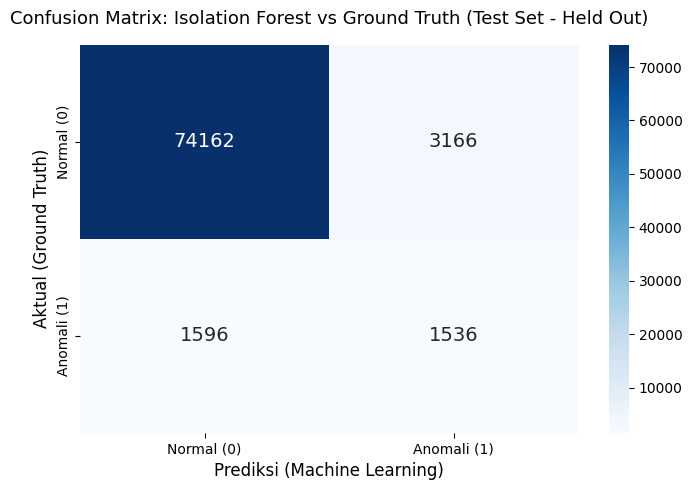

In [10]:
# ==============================================================================
# MAIN (PIPELINE EKSEKUSI LENGKAP)
# ==============================================================================
if __name__ == "__main__":

    ssl_path    = os.path.join(DATASET_DIR, SSL_FILE)
    conn_path   = os.path.join(DATASET_DIR, CONN_FILE)
    output_path = os.path.join(DATASET_DIR, OUTPUT_FILE)

    if not os.path.exists(ssl_path) or not os.path.exists(conn_path):
        print(f"❌ Error: File master tidak ditemukan di {DATASET_DIR}")
        exit(1)

    # 1. Merge Data
    df = merge_datasets(ssl_path, conn_path, output_path)

    # 2. Pelabelan Ground Truth (sekarang menghasilkan df['label_source'] juga)
    df = generate_ground_truth(df, ja4db_path='ja4db.json', blacklist_path='malware-domains.txt')

    print(f"💾 Menyimpan data beserta label ke {output_path}...")
    df.to_csv(output_path, sep=',', index=False)

    # 3. Feature Engineering
    (X, feature_cols, ja4a_freq_map,
     ja4b_freq_map, ja4c_freq_map,
     le_state) = feature_engineering(df)

    # -------------------------------------------------------------------
    # CATATAN KETERBATASAN PENELITIAN:
    # Pipeline ini HANYA memproses koneksi TLS yang berhasil di-fingerprint
    # JA4 oleh Zeek (baris tanpa JA4 valid dibuang di merge_datasets()).
    # Artinya traffic non-TLS, traffic TLS yang gagal di-parse, atau
    # protokol lain (mis. QUIC yang tidak tercakup) TIDAK ikut dievaluasi.
    # Hasil precision/recall/F1 pada bab ini HANYA berlaku untuk cakupan
    # tersebut dan sebaiknya dinyatakan eksplisit sebagai batasan penelitian
    # ,bukan digeneralisasi ke seluruh traffic jaringan.
    # -------------------------------------------------------------------
    print(f"ℹ️  Catatan: evaluasi hanya mencakup {len(df):,} koneksi TLS dengan JA4 valid "
          f"(lihat batasan penelitian di Bab 5).")

    # 4. TRAINING & TUNING MODEL (split train/test valid, bobot konsisten)
    result = train_and_tune_model(
        X, df['label'], label_source=df['label_source'],
        test_size=0.20, random_state=42, cv_folds=3
    )

    model    = result['model']
    scaler   = result['scaler']
    weighter = result['weighter']

    # 5. EVALUASI MODEL — HANYA PADA TEST SET (bukan seluruh data)
    y_pred_test = np.where(model.predict(result['X_test_w']) == -1, 1, 0)
    evaluate_model(result['y_test'], y_pred_test)

    # 6. Simpan Artifacts (termasuk weighter)
    save_artifacts(model, scaler, weighter, le_state,
                   ja4a_freq_map, ja4b_freq_map,
                   ja4c_freq_map, feature_cols)

    print("\n🎉 SELURUH PROSES SELESAI — Model hasil tuning (train/test split valid) siap digunakan.")
    print(f"   Ringkasan metrik test set: {result['test_metrics']}")
    print(f"   Parameter terpilih (via CV pada train set): {result['best_params']}")


 📑 GENERATOR DATA UNTUK BAB 4: HASIL DAN PEMBAHASAN (REVISI) 📑

--- 4.1 & 4.2 HASIL PREPROCESSING & CLEANING ---
Total baris data jaringan valid (setelah filter JA4): 402,299 baris
Total baris setelah penghapusan duplikasi UID   : 402,299 baris
Keterangan: cakupan hanya koneksi TLS dengan JA4 valid (lihat batasan penelitian Bab 5).

--- 4.3 HASIL FEATURE ENGINEERING (DEKOMPOSISI JA4) ---
                                    JA4       JA4_a         JA4_b         JA4_c
0  t13d1516h2_8daaf6152771_d8a2da3f94cd  t13d1516h2  8daaf6152771  d8a2da3f94cd
1  t13d1516h2_8daaf6152771_d8a2da3f94cd  t13d1516h2  8daaf6152771  d8a2da3f94cd
2  t13d1713h1_5b57614c22b0_eca864cca44a  t13d1713h1  5b57614c22b0  eca864cca44a
3  t13d1516h2_8daaf6152771_d8a2da3f94cd  t13d1516h2  8daaf6152771  d8a2da3f94cd
4  t13d201200_2b729b4bf6f3_e24568c0d440  t13d201200  2b729b4bf6f3  e24568c0d440

Kardinalitas - JA4_a: 349 | JA4_b: 203 | JA4_c: 260

--- 4.4 PEMBOBOTAN FITUR (KONSISTEN, SATU SUMBER KEBENARAN) ---
Bobot fitur

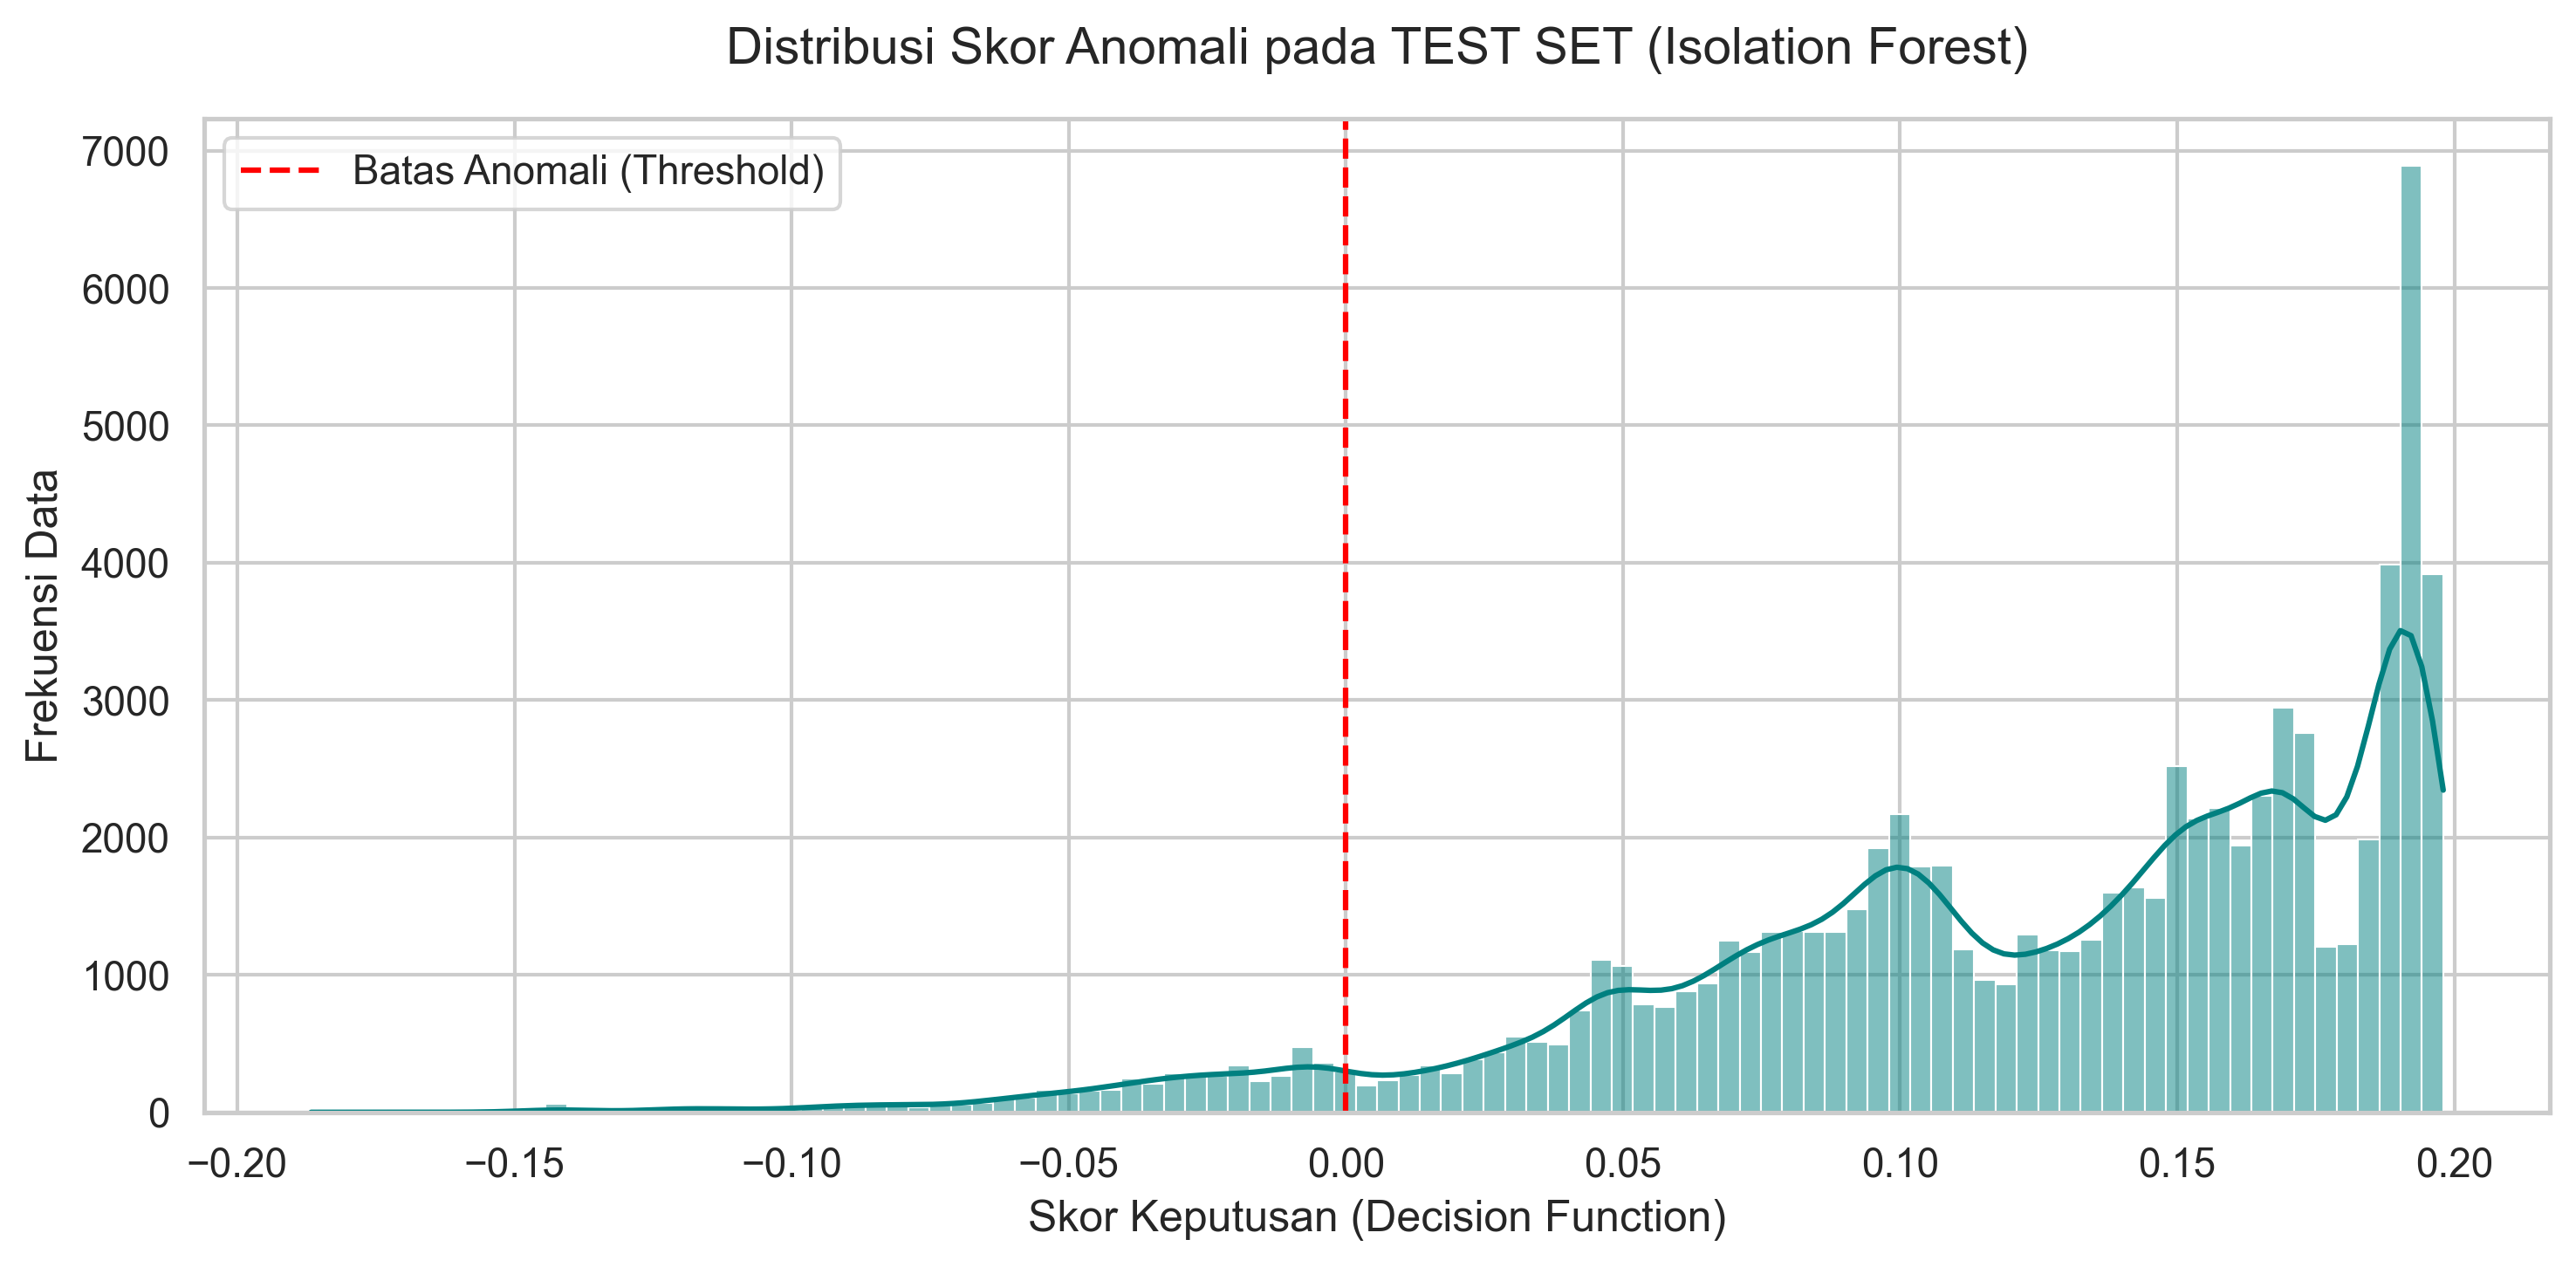

In [10]:
# ==============================================================================
# GENERATOR DATA UNTUK BAB 4 — REVISI (memakai hasil evaluasi test-set yang valid)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300

print("==================================================================")
print(" 📑 GENERATOR DATA UNTUK BAB 4: HASIL DAN PEMBAHASAN (REVISI) 📑")
print("==================================================================\n")

print("--- 4.1 & 4.2 HASIL PREPROCESSING & CLEANING ---")
print(f"Total baris data jaringan valid (setelah filter JA4): {len(df):,} baris")
print(f"Total baris setelah penghapusan duplikasi UID   : {df['uid'].nunique():,} baris")
print("Keterangan: cakupan hanya koneksi TLS dengan JA4 valid (lihat batasan penelitian Bab 5).\n")

print("--- 4.3 HASIL FEATURE ENGINEERING (DEKOMPOSISI JA4) ---")
print(df[['JA4', 'JA4_a', 'JA4_b', 'JA4_c']].head(5).to_string())
print(f"\nKardinalitas - JA4_a: {df['JA4_a'].nunique()} | JA4_b: {df['JA4_b'].nunique()} | JA4_c: {df['JA4_c'].nunique()}\n")

print("--- 4.4 PEMBOBOTAN FITUR (KONSISTEN, SATU SUMBER KEBENARAN) ---")
print(f"Bobot fitur yang dipakai di training MAUPUN evaluasi: {FEATURE_WEIGHTS}")
print("(Tidak ada lagi perbedaan angka antara kode training dan kode laporan.)\n")

print("--- 4.5 & 4.6 PEMISAHAN DATASET (TRAIN-TEST SPLIT YANG BENAR-BENAR DIPAKAI) ---")
n_test = len(result['y_test'])
n_train = len(df) - n_test
print(f"Proporsi Pemisahan Dataset : 80% Pelatihan / 20% Pengujian (stratified by label)")
print(f"Total Data Pelatihan (Train): {n_train:,} baris")
print(f"Total Data Pengujian (Test) : {n_test:,} baris")
print("Split ini dilakukan SEBELUM scaler/bobot di-fit, dan model dievaluasi HANYA pada test set.\n")

print("--- 4.7 HASIL PELATIHAN DAN OPTIMASI MODEL ISOLATION FOREST ---")
print(f"Parameter Hasil Tuning (via cross-validation di TRAIN set): {result['best_params']}")
print(f"Rata-rata F1 cross-validation (train): {result['cv_f1']:.4f}")
print(f"Metrik pada TEST SET (data yang tidak pernah dilihat model):")
print(f"   F1        = {result['test_metrics']['f1']:.4f}")
print(f"   Precision = {result['test_metrics']['precision']:.4f}")
print(f"   Recall    = {result['test_metrics']['recall']:.4f}")

scores_test = model.decision_function(result['X_test_w'])
pred_test = np.where(model.predict(result['X_test_w']) == -1, 1, 0)

plt.figure(figsize=(10, 5))
sns.histplot(scores_test, bins=100, kde=True, color='teal')
if (pred_test == 1).any():
    plt.axvline(x=scores_test[pred_test == 1].max(), color='red', linestyle='--', label='Batas Anomali (Threshold)')
plt.title('Distribusi Skor Anomali pada TEST SET (Isolation Forest)', fontsize=14, pad=15)
plt.xlabel('Skor Keputusan (Decision Function)', fontsize=12)
plt.ylabel('Frekuensi Data', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('grafik_bab4_distribusi_skor.png')
print("✅ Grafik distribusi skor (test set) disimpan sebagai 'grafik_bab4_distribusi_skor.png'.")


✅ Gambar Kurva ROC (test set) berhasil disimpan sebagai 'kurva_roc.png'


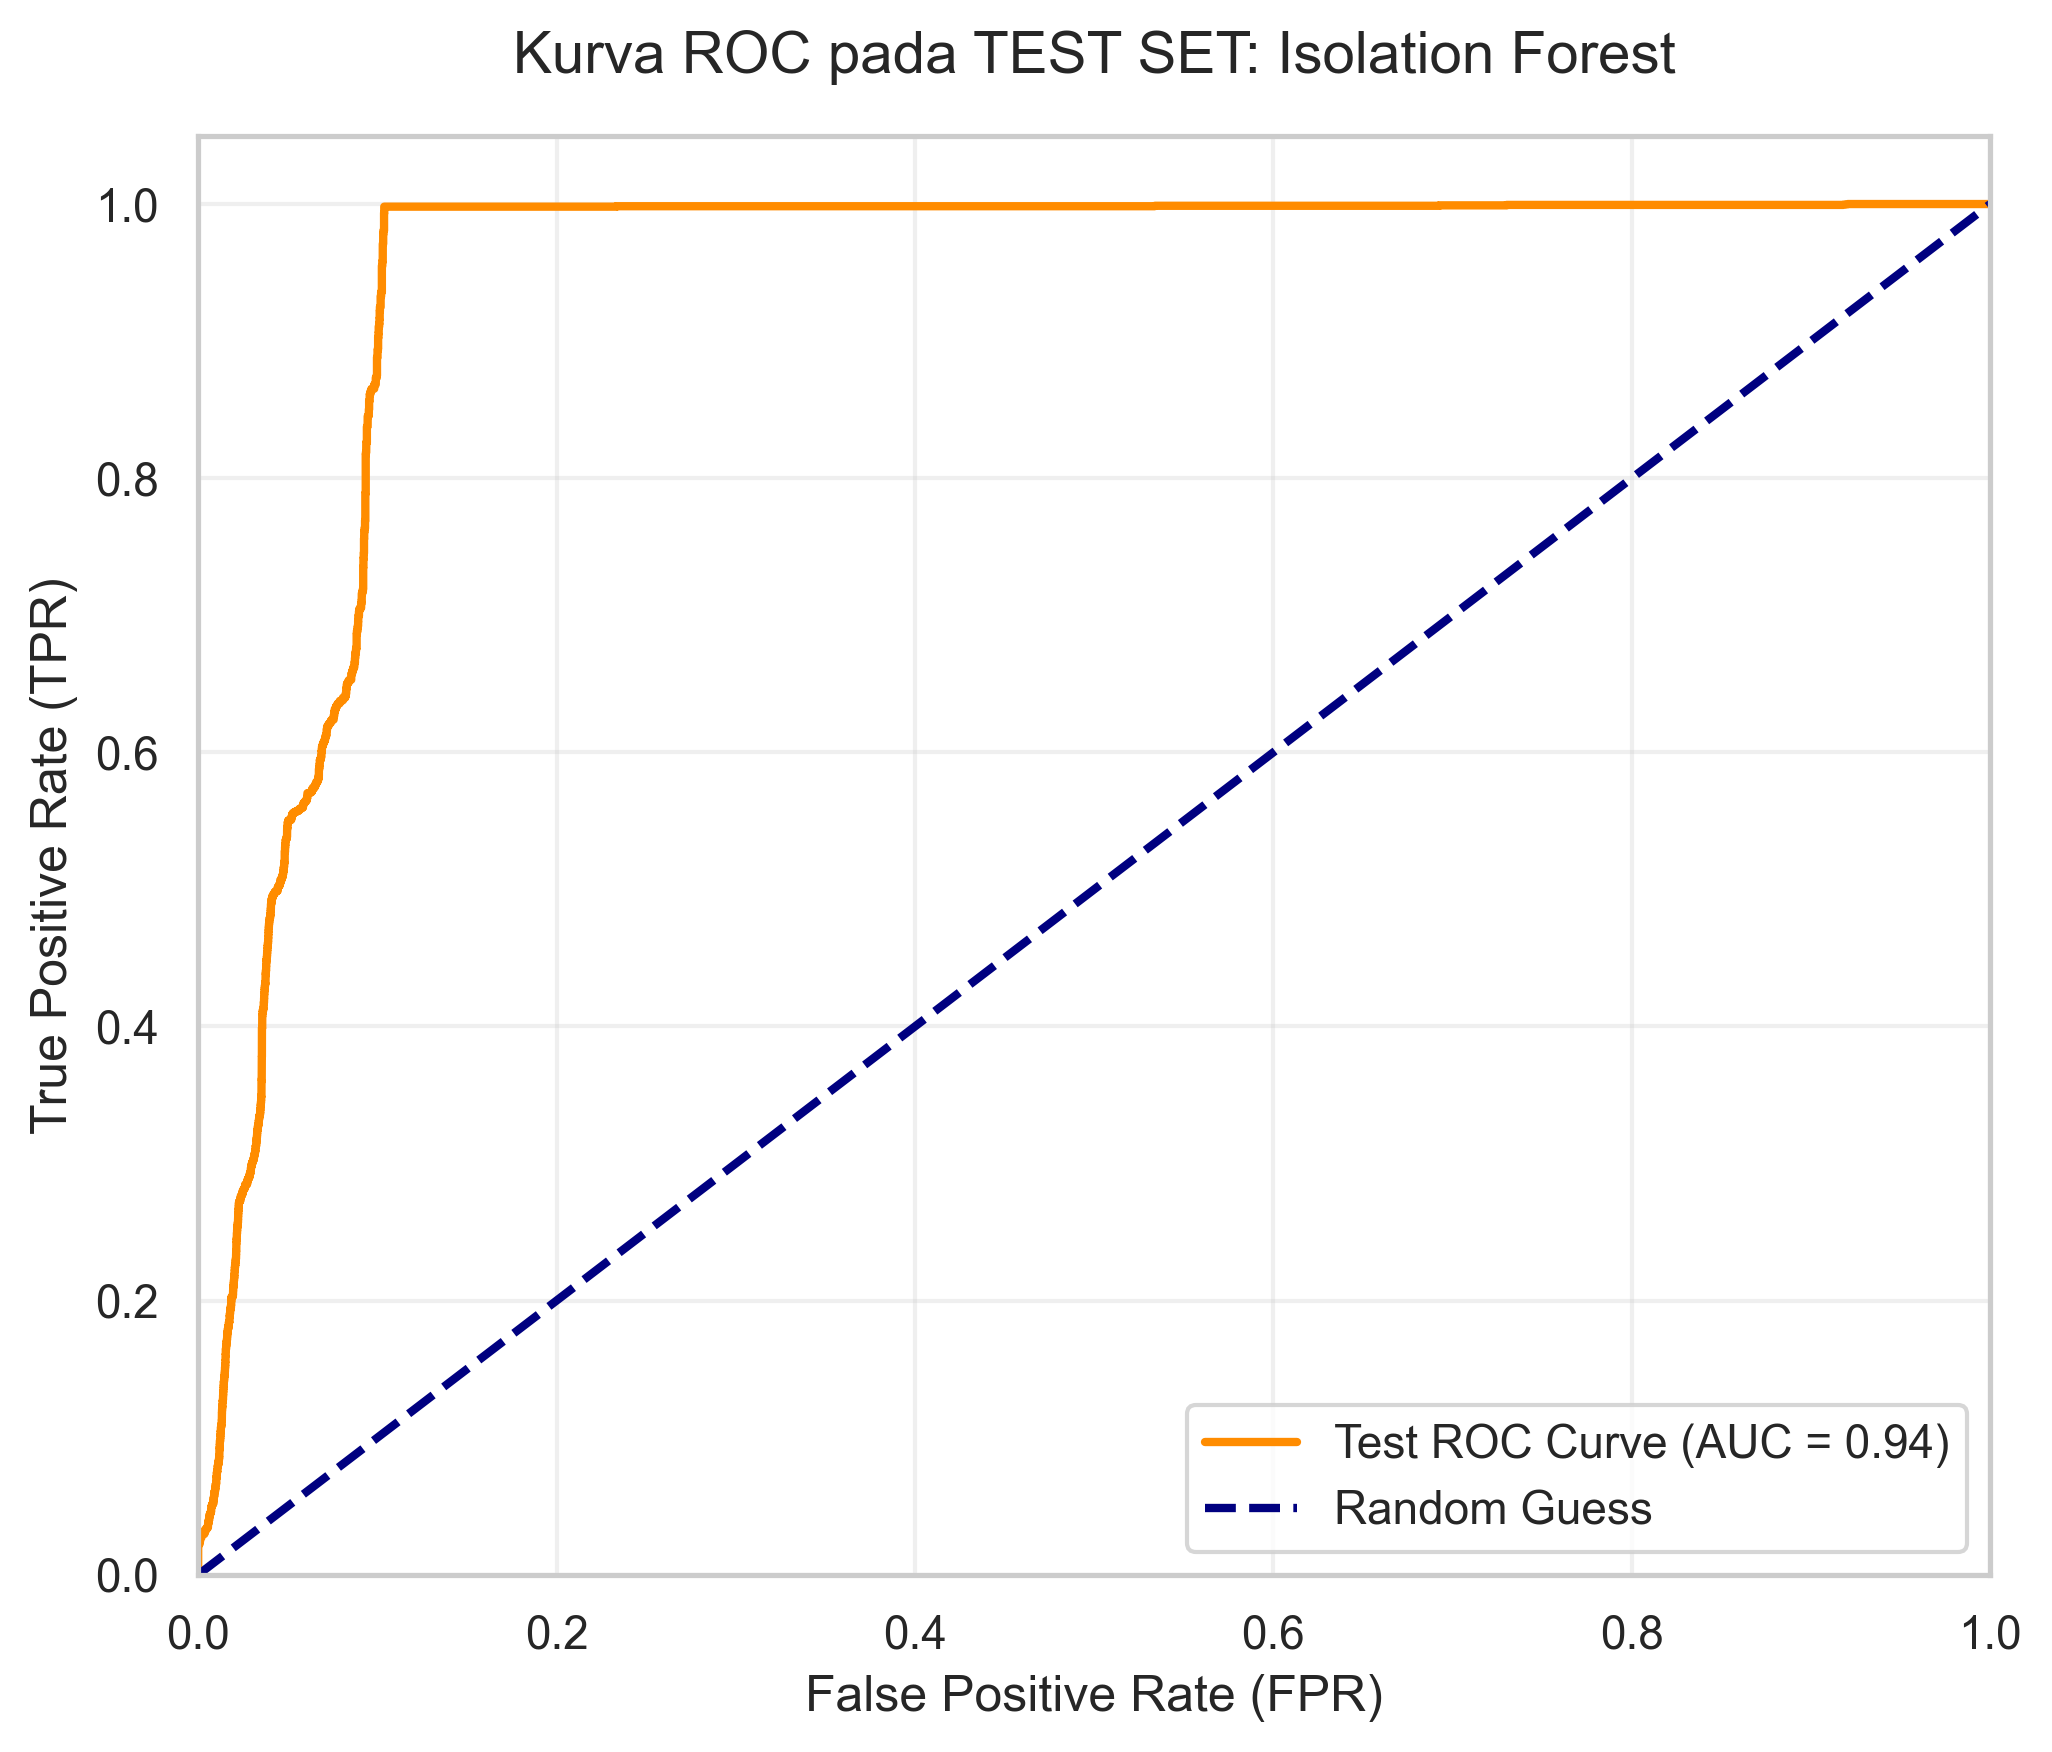

In [11]:
# ==============================================================================
# KURVA ROC — REVISI (dihitung pada TEST SET, bukan seluruh data)
# ==============================================================================
from sklearn.metrics import roc_curve, auc

y_scores_test = -model.decision_function(result['X_test_w'])
fpr, tpr, thresholds = roc_curve(result['y_test'], y_scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Test ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Kurva ROC pada TEST SET: Isolation Forest', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kurva_roc.png', dpi=300)
print("✅ Gambar Kurva ROC (test set) berhasil disimpan sebagai 'kurva_roc.png'")


In [14]:
# ==============================================================================
# EKSPLORASI JUMLAH & VARIASI PER SUMBER LABEL (label_source)
# ==============================================================================
# Jalankan cell ini SETELAH generate_ground_truth() (variabel `df` sudah ada
# dan sudah punya kolom 'label_source').

print("=" * 78)
print("RINGKASAN JUMLAH PER SUMBER LABEL")
print("=" * 78)
summary = df['label_source'].value_counts().reset_index()
summary.columns = ['label_source', 'jumlah_baris']
summary['persentase (%)'] = (summary['jumlah_baris'] / len(df) * 100).round(3)
print(summary.to_string(index=False))

# Kolom yang mau dicek variasinya -- disesuaikan otomatis kalau ada yang
# tidak tersedia di dataset Anda (mis. beda penamaan kolom).
kolom_cek = ['SNI', 'JA4', 'id.orig_h', 'id.resp_h', 'Conn_State', 'proto']
kolom_cek = [c for c in kolom_cek if c in df.columns]

for src in ['no_sni_rule', 'ja4_threat_db', 'sni_blacklist']:
    subset = df[df['label_source'] == src]
    if len(subset) == 0:
        print(f"\n(Tidak ada baris dengan label_source = '{src}')")
        continue

    print("\n" + "=" * 78)
    print(f"DETAIL: {src}  (total {len(subset):,} baris)")
    print("=" * 78)

    print("\n-- Jumlah nilai UNIK (variasi) per kolom --")
    for col in kolom_cek:
        print(f"   {col:<12s}: {subset[col].nunique()} nilai unik")

    if 'SNI' in subset.columns:
        print("\n-- Top 10 SNI paling sering muncul --")
        print(subset['SNI'].value_counts().head(10).to_string())

    if 'JA4' in subset.columns:
        print("\n-- Top 10 JA4 paling sering muncul --")
        print(subset['JA4'].value_counts().head(10).to_string())

    if 'id.resp_h' in subset.columns:
        print("\n-- Top 10 IP tujuan (id.resp_h) paling sering muncul --")
        print(subset['id.resp_h'].value_counts().head(10).to_string())

    print("\n-- Contoh baris (sampel acak, maks 5) --")
    cols_preview = ['uid', 'JA4', 'SNI', 'id.orig_h', 'id.resp_h',
                    'Conn_State', 'proto', 'Duration']
    cols_preview = [c for c in cols_preview if c in subset.columns]
    print(subset[cols_preview].sample(min(5, len(subset)), random_state=42).to_string(index=False))

# --- Opsional: simpan tiap kelompok ke CSV terpisah untuk lampiran skripsi ---
os.makedirs('lampiran_label_source', exist_ok=True)
for src in ['no_sni_rule', 'ja4_threat_db', 'sni_blacklist']:
    subset = df[df['label_source'] == src]
    if len(subset) > 0:
        fname = f'lampiran_label_source/{src}.csv'
        subset.to_csv(fname, index=False)
        print(f"\n💾 Disimpan: {fname} ({len(subset):,} baris)")

RINGKASAN JUMLAH PER SUMBER LABEL
 label_source  jumlah_baris  persentase (%)
       normal        386640          96.108
  no_sni_rule         15567           3.870
ja4_threat_db            50           0.012
sni_blacklist            42           0.010

DETAIL: no_sni_rule  (total 15,567 baris)

-- Jumlah nilai UNIK (variasi) per kolom --
   SNI         : 1 nilai unik
   JA4         : 51 nilai unik
   id.orig_h   : 462 nilai unik
   id.resp_h   : 95 nilai unik
   Conn_State  : 8 nilai unik
   proto       : 2 nilai unik

-- Top 10 SNI paling sering muncul --
SNI
-    15567

-- Top 10 JA4 paling sering muncul --
JA4
t13i1515h2_8daaf6152771_e5627efa2ab1    4077
t13i1515h2_8daaf6152771_ef90417dd72d    3224
t13i1713h1_5b57614c22b0_fadfdae04b4e    1961
t13i171100_5b57614c22b0_02c8e53ee398    1880
t13i1515h2_8daaf6152771_9b887d9acb53    1653
t13i1711h1_5b57614c22b0_40271e0a5736    1025
t13i1515h2_8daaf6152771_62c0e06d6f68     633
q13i0309h3_55b375c5d22e_cd85d2d88918     288
t13i170900_5b5761

In [12]:
!pip freeze > requirements.txt
